In [64]:
#Brownian motion defines price simulation and is imperative to the black scholes model and lends itseld swimmingly to 
# price simulation for statistical 

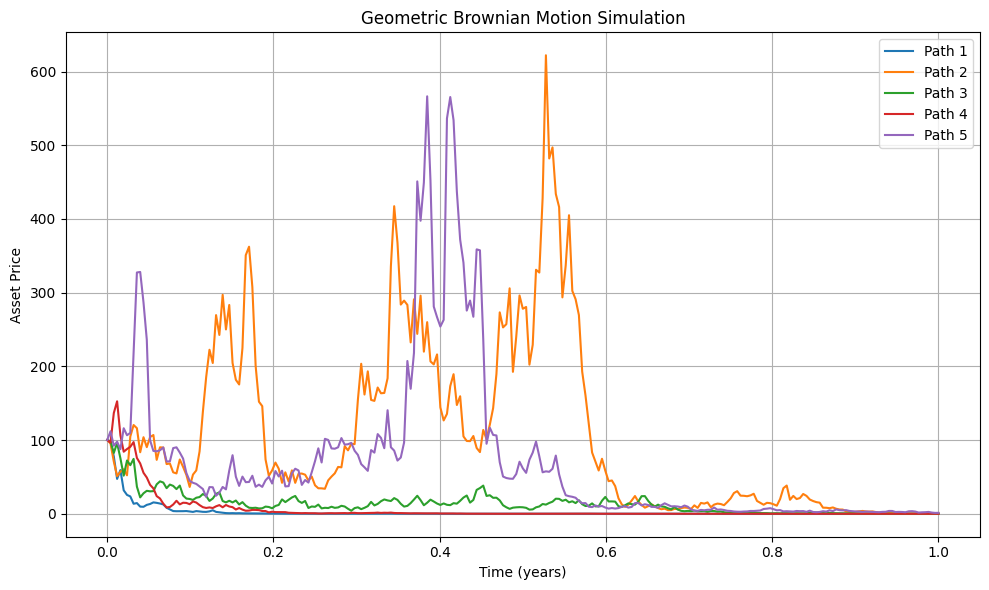

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for Geometric Brownian Motion
mu = 1     # Drift coefficient
sigma = 4  # Volatility coefficient
S0 = 100       # Initial asset price
T = 1.0        # Time horizon (in years)
n_steps = 252  # Number of time steps (e.g. trading days)
n_paths = 5    # Number of sample paths

def simulate_gbm(mu, sigma, S0, T, n_steps, n_paths):
    dt = T / n_steps
    time_grid = np.linspace(0, T, n_steps + 1)
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = S0
    for i in range(n_paths):
        random_increments = np.random.normal(0, np.sqrt(dt), n_steps)
        cumulative = np.cumsum((mu - 0.5 * sigma**2) * dt + sigma * random_increments)
        paths[i, 1:] = S0 * np.exp(cumulative)
    return time_grid, paths

# Simulate paths
time_grid, paths = simulate_gbm(mu, sigma, S0, T, n_steps, n_paths)

# Plot the simulated paths
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(time_grid, paths[i], lw=1.5, label=f"Path {i+1}")
plt.title("Geometric Brownian Motion Simulation")
plt.xlabel("Time (years)")
plt.ylabel("Asset Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


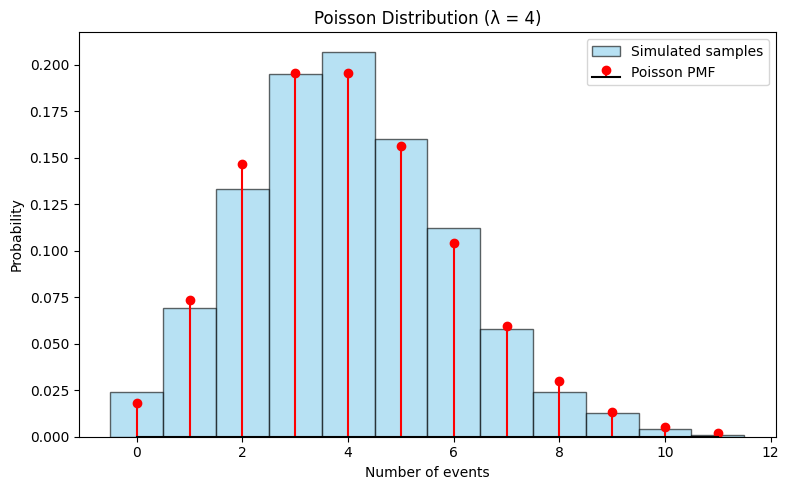

In [66]:
# Simulating and plotting a Poisson distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parameter λ (mean rate of events)
lam = 4

# Generate 1,000 samples from Poisson(λ)
samples = np.random.poisson(lam, size=1000)

# Define range of x-values for plotting the PMF
x = np.arange(0, 12)

# Compute the theoretical PMF
pmf = poisson.pmf(x, lam)

# Plot histogram of simulated samples
plt.figure(figsize=(8, 5))
plt.hist(
    samples,
    bins=range(0, 13),
    density=True,
    alpha=0.6,
    color='skyblue',
    edgecolor='black',
    align='left',
    label='Simulated samples'
)

# Plot theoretical Poisson PMF
plt.stem(x, pmf, linefmt='r-', markerfmt='ro', basefmt='k-', label='Poisson PMF')

plt.xlabel('Number of events')
plt.ylabel('Probability')
plt.title(f'Poisson Distribution (λ = {lam})')
plt.legend()
plt.tight_layout()
plt.show()


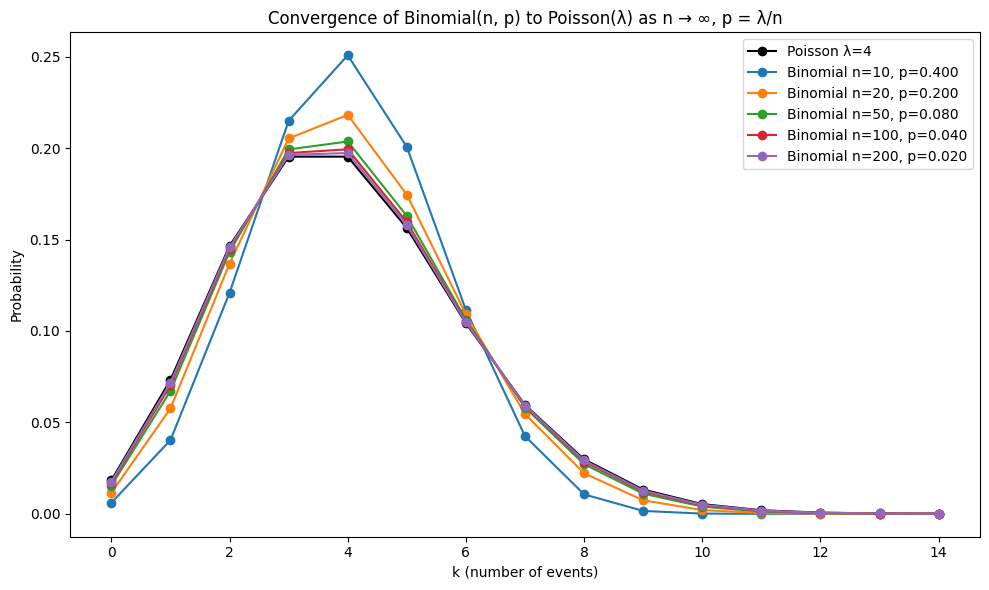

In [69]:
# Demonstrating the convergence of Binomial(n, p) to a Poisson(λ) distribution
# as n → ∞ and p → 0 with λ = n * p fixed.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

lam = 4  # Desired Poisson rate parameter

# Range of k values to plot
k = np.arange(0, 15)

# Theoretical Poisson PMF for comparison
poisson_pmf = poisson.pmf(k, lam)

# Binomial parameters: larger n means smaller p (p = λ / n)
n_values = [10, 20, 50, 100, 200]

plt.figure(figsize=(10, 6))
plt.plot(k, poisson_pmf, 'k-', marker='o', label='Poisson λ=4')

# Plot Binomial PMFs for increasing n
for n in n_values:
    p = lam / n
    binom_pmf = binom.pmf(k, n, p)
    plt.plot(k, binom_pmf, marker='o', label=f'Binomial n={n}, p={p:.3f}')

plt.xlabel('k (number of events)')
plt.ylabel('Probability')
plt.title('Convergence of Binomial(n, p) to Poisson(λ) as n → ∞, p = λ/n')
plt.legend()
plt.tight_layout()
plt.show()


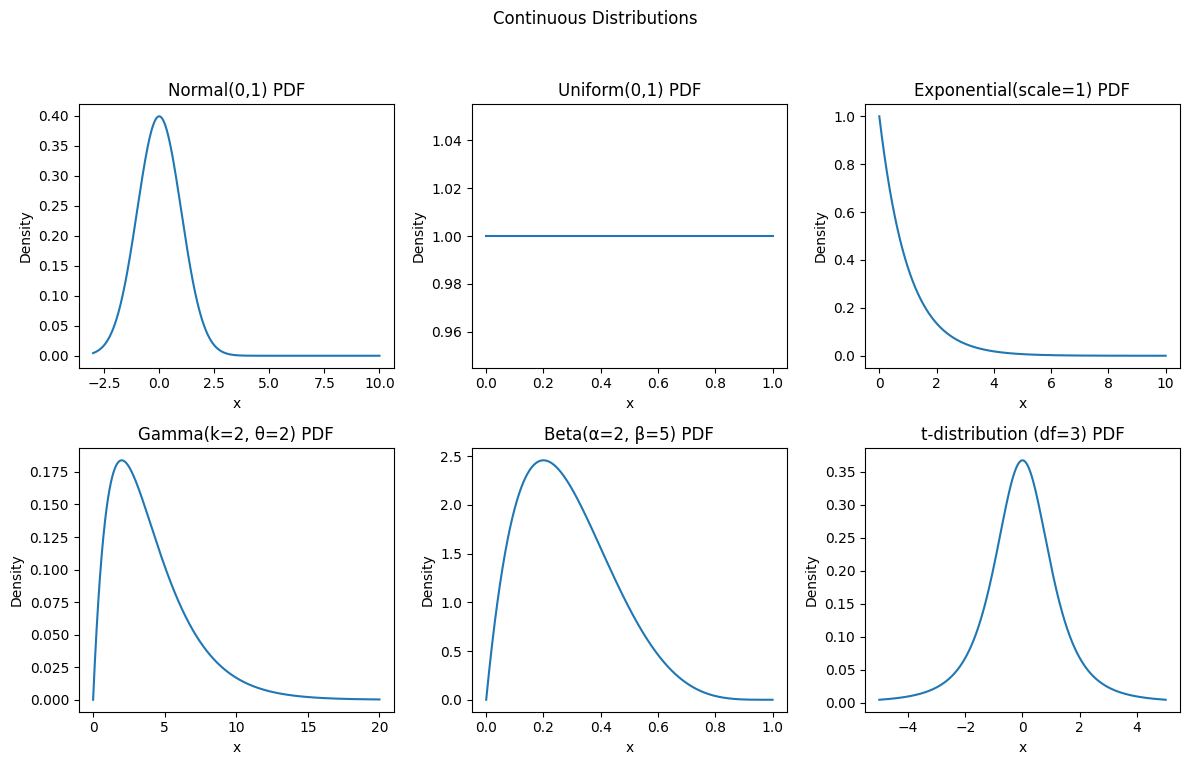

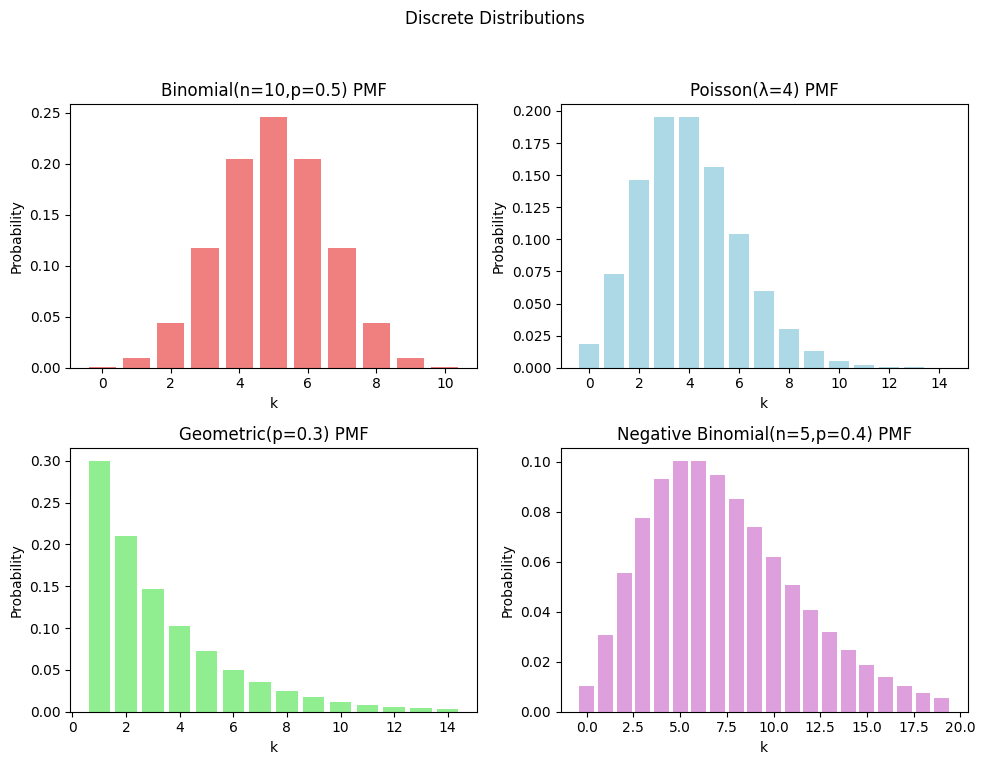

In [70]:
# Visualizing several common probability distributions

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, expon, gamma, beta, binom, poisson, geom, nbinom, t

# Continuous distributions
fig1, axs1 = plt.subplots(2, 3, figsize=(12, 8))
fig1.suptitle('Continuous Distributions')

# Normal distribution
x_norm = np.linspace(-3, 10, 1000)
axs1[0, 0].plot(x_norm, norm.pdf(x_norm, 0, 1))
axs1[0, 0].set_title('Normal(0,1) PDF')
axs1[0, 0].set_xlabel('x')
axs1[0, 0].set_ylabel('Density')

# Uniform distribution
x_unif = np.linspace(0, 1, 1000)
axs1[0, 1].plot(x_unif, uniform.pdf(x_unif, 0, 1))
axs1[0, 1].set_title('Uniform(0,1) PDF')
axs1[0, 1].set_xlabel('x')
axs1[0, 1].set_ylabel('Density')

# Exponential distribution
x_expon = np.linspace(0, 10, 1000)
axs1[0, 2].plot(x_expon, expon.pdf(x_expon, scale=1))
axs1[0, 2].set_title('Exponential(scale=1) PDF')
axs1[0, 2].set_xlabel('x')
axs1[0, 2].set_ylabel('Density')

# Gamma distribution
x_gamma = np.linspace(0, 20, 1000)
axs1[1, 0].plot(x_gamma, gamma.pdf(x_gamma, a=2, scale=2))
axs1[1, 0].set_title('Gamma(k=2, θ=2) PDF')
axs1[1, 0].set_xlabel('x')
axs1[1, 0].set_ylabel('Density')

# Beta distribution
x_beta = np.linspace(0, 1, 1000)
axs1[1, 1].plot(x_beta, beta.pdf(x_beta, a=2, b=5))
axs1[1, 1].set_title('Beta(α=2, β=5) PDF')
axs1[1, 1].set_xlabel('x')
axs1[1, 1].set_ylabel('Density')

# Student's t distribution
x_t = np.linspace(-5, 5, 1000)
axs1[1, 2].plot(x_t, t.pdf(x_t, df=3))
axs1[1, 2].set_title('t-distribution (df=3) PDF')
axs1[1, 2].set_xlabel('x')
axs1[1, 2].set_ylabel('Density')

fig1.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Discrete distributions
fig2, axs2 = plt.subplots(2, 2, figsize=(10, 8))
fig2.suptitle('Discrete Distributions')

# Binomial distribution
k_binom = np.arange(0, 11)
axs2[0, 0].bar(k_binom, binom.pmf(k_binom, n=10, p=0.5), color='lightcoral')
axs2[0, 0].set_title('Binomial(n=10,p=0.5) PMF')
axs2[0, 0].set_xlabel('k')
axs2[0, 0].set_ylabel('Probability')

# Poisson distribution
k_poisson = np.arange(0, 15)
axs2[0, 1].bar(k_poisson, poisson.pmf(k_poisson, mu=4), color='lightblue')
axs2[0, 1].set_title('Poisson(λ=4) PMF')
axs2[0, 1].set_xlabel('k')
axs2[0, 1].set_ylabel('Probability')

# Geometric distribution
k_geom = np.arange(1, 15)
axs2[1, 0].bar(k_geom, geom.pmf(k_geom, p=0.3), color='lightgreen')
axs2[1, 0].set_title('Geometric(p=0.3) PMF')
axs2[1, 0].set_xlabel('k')
axs2[1, 0].set_ylabel('Probability')

# Negative Binomial distribution
k_nbinom = np.arange(0, 20)
axs2[1, 1].bar(k_nbinom, nbinom.pmf(k_nbinom, n=5, p=0.4), color='plum')
axs2[1, 1].set_title('Negative Binomial(n=5,p=0.4) PMF')
axs2[1, 1].set_xlabel('k')
axs2[1, 1].set_ylabel('Probability')

fig2.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


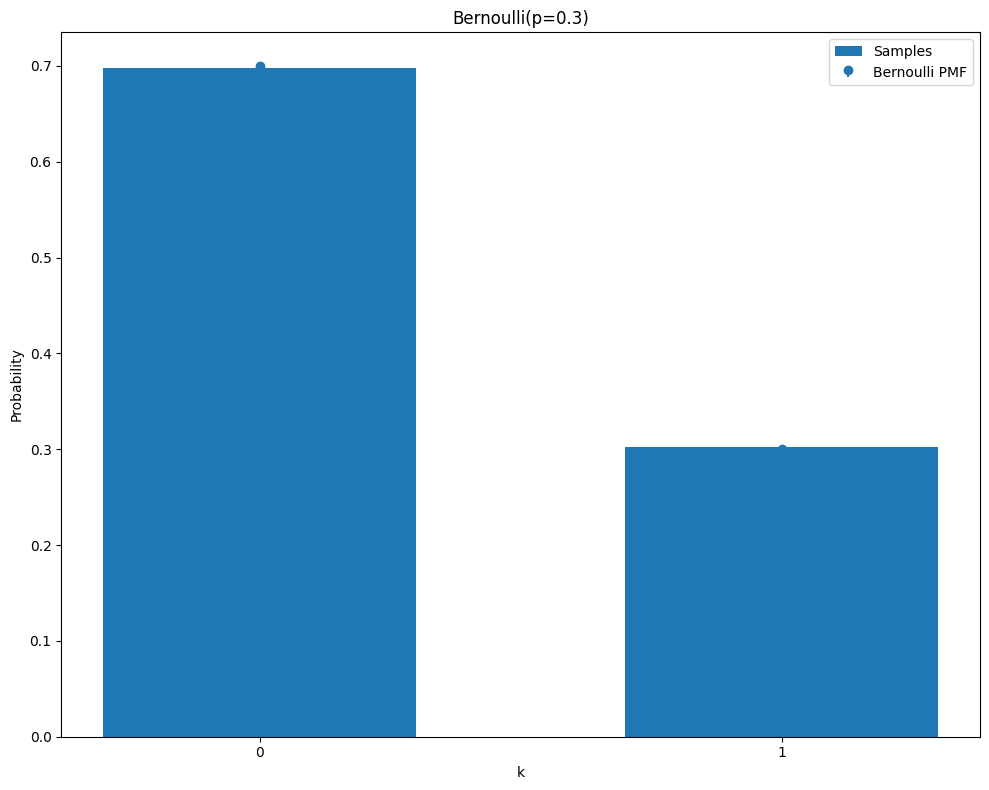

In [1]:
import numpy as np
import matplotlib.pyplot as plt

p = 0.3
N = 2000

x = np.array([0, 1])
pmf = np.array([1 - p, p])
samples = np.random.binomial(1, p, size=N)

plt.figure(figsize=(10,8))
plt.hist(samples, bins=[-0.5,0.5,1.5], density=True, align='mid', rwidth=0.6, label='Samples')
markerline, stemlines, baseline = plt.stem(x, pmf, label='Bernoulli PMF', basefmt=' ')
plt.xticks([0,1])
plt.xlabel('k')
plt.ylabel('Probability')
plt.title(f'Bernoulli(p={p})')
plt.legend()
plt.tight_layout()
plt.show()
